In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# Show all files attached to this notebook

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link/cancer patient data sets.csv


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link/cancer patient data sets.csv")

df.head()

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


In [4]:
print(df["Level"].value_counts())
print(df["Level"].unique())

Level
High      365
Medium    332
Low       303
Name: count, dtype: int64
['Low' 'Medium' 'High']


In [5]:
# Check dataset information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

In [6]:
# Check first few rows

df.head()

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


In [7]:
# ==========================================
# DATA CLEANING
# ==========================================

# Remove useless columns

df = df.drop("index", axis=1)
df = df.drop("Patient Id", axis=1)

# Check remaining columns

print(df.columns)

# Convert target labels into numbers
# Low -> 0
# Medium -> 1
# High -> 2

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Level"] = label_encoder.fit_transform(df["Level"])

# Verify conversion

print(df["Level"].value_counts())

# Display first rows

df.head()

Index(['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring', 'Level'],
      dtype='object')
Level
0    365
2    332
1    303
Name: count, dtype: int64


,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,1
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,2
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,0
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,0
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,0


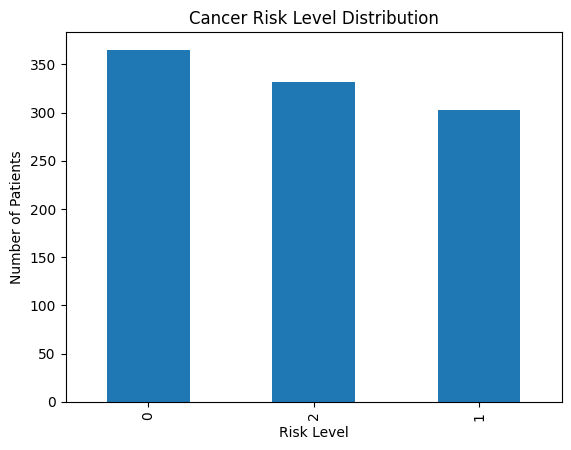

In [8]:
import matplotlib.pyplot as plt

# Count number of patients in each class

df["Level"].value_counts().plot(kind="bar")

plt.title("Cancer Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")

plt.show()

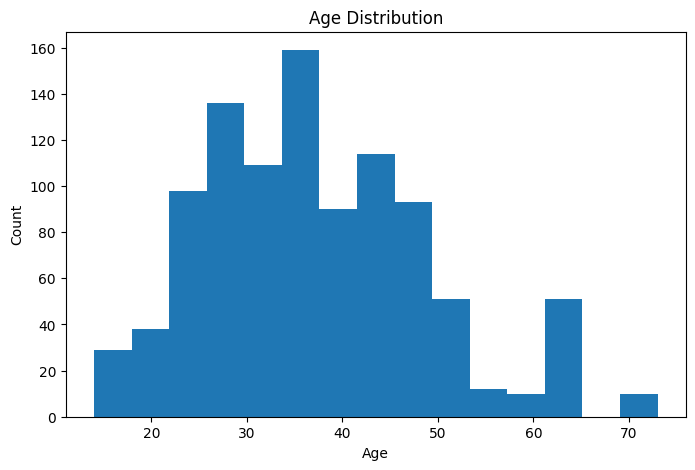

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

In [10]:
# Features (inputs)

X = df.drop("Level", axis=1)

# Target (output)

y = df["Level"]

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (1000, 23)
Target Shape: (1000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (800, 23)
Testing Data Shape: (200, 23)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [13]:
# ==========================================
# LOGISTIC REGRESSION
# ==========================================

# Import Logistic Regression model

from sklearn.linear_model import LogisticRegression

# Create the model
# max_iter=1000 gives the model enough iterations to learn

lr = LogisticRegression(max_iter=1000)

# Train the model using training data

lr.fit(X_train, y_train)

# Predict on test data

lr_pred = lr.predict(X_test)

# Calculate accuracy

from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy =", lr_acc)

Logistic Regression Accuracy = 1.0


In [14]:
# ==========================================
# DECISION TREE
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# Create model

dt = DecisionTreeClassifier(random_state=42)

# Train model

dt.fit(X_train, y_train)

# Predict

dt_pred = dt.predict(X_test)

# Accuracy

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy =", dt_acc)

Decision Tree Accuracy = 1.0


In [15]:
# ==========================================
# KNN
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

# Create model
# n_neighbors=5 means look at the 5 nearest patients

knn = KNeighborsClassifier(n_neighbors=5)

# Train model

knn.fit(X_train, y_train)

# Predict

knn_pred = knn.predict(X_test)

# Accuracy

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy =", knn_acc)

KNN Accuracy = 1.0


In [16]:
# ==========================================
# SUPPORT VECTOR MACHINE
# ==========================================

from sklearn.svm import SVC

# Create model

svm = SVC()

# Train

svm.fit(X_train, y_train)

# Predict

svm_pred = svm.predict(X_test)

# Accuracy

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy =", svm_acc)

SVM Accuracy = 1.0


In [17]:
# ==========================================
# RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# Create model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train

rf.fit(X_train, y_train)

# Predict

rf_pred = rf.predict(X_test)

# Accuracy

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy =", rf_acc)

Random Forest Accuracy = 1.0


In [18]:
# ==========================================
# MODEL COMPARISON
# ==========================================

print("Logistic Regression :", lr_acc)

print("Decision Tree       :", dt_acc)

print("KNN                 :", knn_acc)

print("SVM                 :", svm_acc)

print("Random Forest       :", rf_acc)

Logistic Regression : 1.0
Decision Tree       : 1.0
KNN                 : 1.0
SVM                 : 1.0
Random Forest       : 1.0


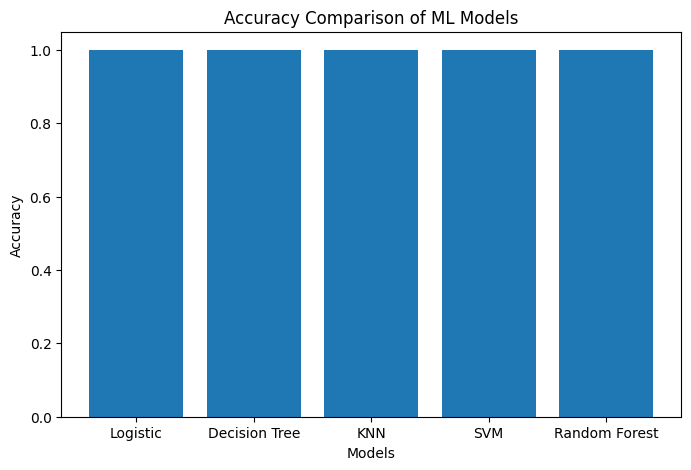

In [19]:
# ==========================================
# ACCURACY COMPARISON GRAPH
# ==========================================

models = [
    "Logistic",
    "Decision Tree",
    "KNN",
    "SVM",
    "Random Forest"
]

accuracies = [
    lr_acc,
    dt_acc,
    knn_acc,
    svm_acc,
    rf_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Accuracy Comparison of ML Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

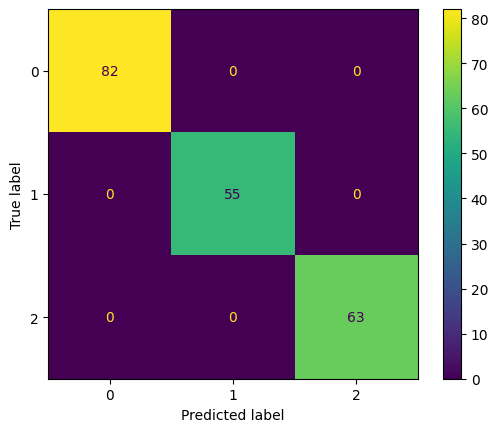

In [20]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()

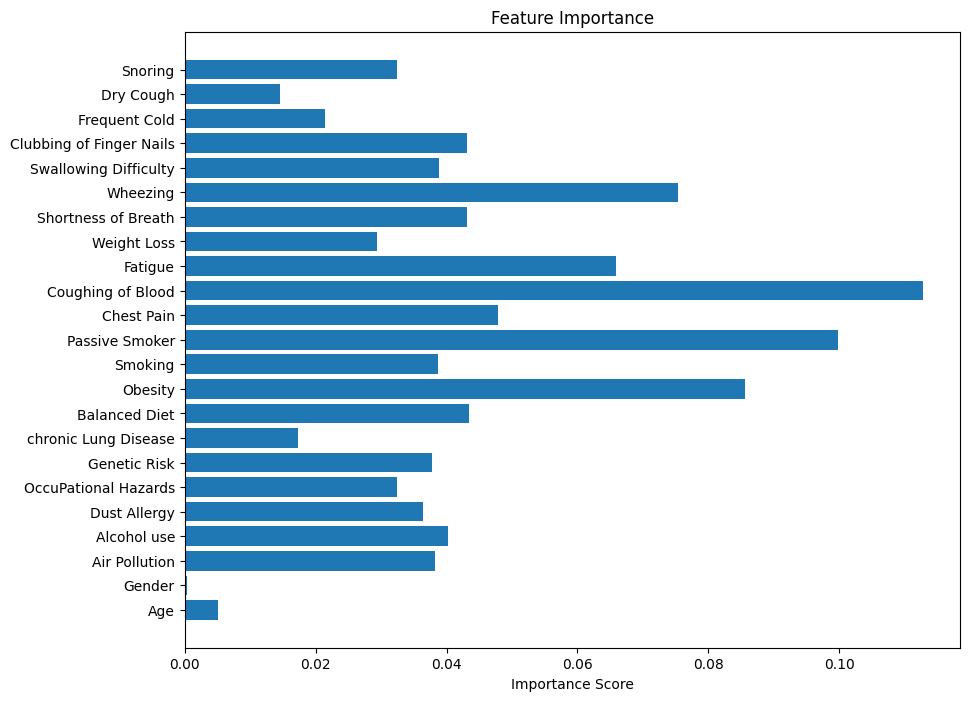

In [21]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,8))

plt.barh(features, importance)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

In [22]:
# ==========================================
# BEST MODEL SELECTION
# ==========================================

results = {
    "Logistic Regression": lr_acc,
    "Decision Tree": dt_acc,
    "KNN": knn_acc,
    "SVM": svm_acc,
    "Random Forest": rf_acc
}

best_model = max(results, key=results.get)

print("Best Model =", best_model)

print("Best Accuracy =", results[best_model])

Best Model = Logistic Regression
Best Accuracy = 1.0


In [23]:
# Check feature correlations

import pandas as pd

correlation = df.corr(numeric_only=True)

print(correlation["Level"].sort_values(ascending=False))

Level                       1.000000
Wheezing                    0.167773
Clubbing of Finger Nails    0.116746
Gender                      0.086222
Age                         0.042631
Snoring                     0.014280
Swallowing Difficulty      -0.012880
Weight Loss                -0.020537
Shortness of Breath        -0.140178
Frequent Cold              -0.171678
Dry Cough                  -0.228720
Dust Allergy               -0.264926
OccuPational Hazards       -0.363748
Fatigue                    -0.403276
Genetic Risk               -0.423382
chronic Lung Disease       -0.432405
Alcohol use                -0.434071
Chest Pain                 -0.494704
Obesity                    -0.561961
Air Pollution              -0.577269
Smoking                    -0.611087
Balanced Diet              -0.618781
Coughing of Blood          -0.631118
Passive Smoker             -0.638409
Name: Level, dtype: float64


In [24]:
print(df.groupby("Level").mean())

             Age    Gender  Air Pollution  Alcohol use  Dust Allergy  \
Level                                                                  
0      37.320548  1.309589       5.693151     6.830137      6.616438   
1      35.412541  1.508251       2.600660     2.231023      3.112211   
2      38.620482  1.406627       2.933735     4.198795      5.442771   

       OccuPational Hazards  Genetic Risk  chronic Lung Disease  \
Level                                                             
0                  6.479452      6.375342              5.827397   
1                  3.000000      2.732673              3.092409   
2                  4.716867      4.292169              3.963855   

       Balanced Diet   Obesity  ...  Coughing of Blood   Fatigue  Weight Loss  \
Level                           ...                                             
0           6.619178  6.682192  ...           7.438356  5.589041     4.468493   
1           3.000000  2.409241  ...           2.861386  2.17

In [25]:
print(X.shape)
print(y.shape)

(1000, 23)
(1000,)


In [26]:
print(X.columns)

Index(['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring'],
      dtype='object')
